In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Importing The Data

In [2]:
df=pd.read_csv('Emp_attrition.csv')

# Understanding The Data

In [3]:
df.head()

,Employee ID,Age,Gender,Years at Company,Number of Employee in Department,Job-Roll,Company Category,State,City,Region,...,Number of Dependents,Job Level,Company Size,Company Tenure (In Months),Remote Work,Leadership Opportunities,Innovation Opportunities,Reputation of employee,Employee Recognition,Attrition
0,8410,31.0,Male,19,6.0,Administration,Media,Rj,Ajmer,North,...,0,Mid,Medium,89.0,No,No,No,Excellent,Medium,Stayed
1,64756,NaN,Female,4,38.0,Administration,Media,Telangana,Warangal,South,...,3,Mid,Medium,21.0,No,No,No,Fair,Low,Stayed
2,30257,NaN,Female,10,45.0,HR Executive,Healthcare,Delhi,Dwarka,North,...,3,Mid,Medium,74.0,No,No,No,Poor,Low,Notice Period
3,65791,NaN,F,7,12.0,Administration,Media,Maharashtra,Mumbai,West,...,2,Mid,Small,50.0,Yes,No,No,Good,Medium,Notice Period
4,65026,NaN,Male,41,37.0,Administration,Media,Delhi,New Delhi,North,...,0,Senior,Medium,68.0,No,No,No,Fair,Medium,Notice Period


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74610 entries, 0 to 74609
Data columns (total 33 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Employee ID                        74610 non-null  int64  
 1   Age                                71427 non-null  float64
 2   Gender                             74610 non-null  object 
 3   Years at Company                   74610 non-null  int64  
 4   Number of Employee in  Department  74358 non-null  float64
 5   Job-Roll                           74610 non-null  object 
 6   Company Category                   74610 non-null  object 
 7   State                              74610 non-null  object 
 8   City                               74610 non-null  object 
 9   Region                             74610 non-null  object 
 10  Monthly Income                     72957 non-null  float64
 11  Work-Life Balance                  74610 non-null  obj

In [5]:
df.isna().sum()

Employee ID                             0
Age                                  3183
Gender                                  0
Years at Company                        0
Number of Employee in  Department     252
Job-Roll                                0
Company Category                        0
State                                   0
City                                    0
Region                                  0
Monthly Income                       1653
Work-Life Balance                       0
Job Satisfaction                        0
Performance Rating                      0
Number of Promotions                    0
Overtime                                0
Bonus                                   0
Increments                              0
No of Leaves                          323
Employee Hire Type                      0
Distance from Home in km             1912
Education Level                         0
Marital Status                          0
Number of Dependents              

In [6]:
df['Age'].isnull().sum()


3183

In [7]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')


# Using Quantile

In [8]:
q1=df['Age'].quantile(0.25)
q1

28.0

In [9]:
q3=df['Age'].quantile(0.75)
q3

49.0

In [10]:
iqr=q1-q3
iqr

-21.0

In [11]:
lb=q1-1.5*iqr
lb

59.5

In [12]:
ub=q3+1.5*iqr
ub

17.5

# Boxplot For Outlier

<Axes: ylabel='Age'>

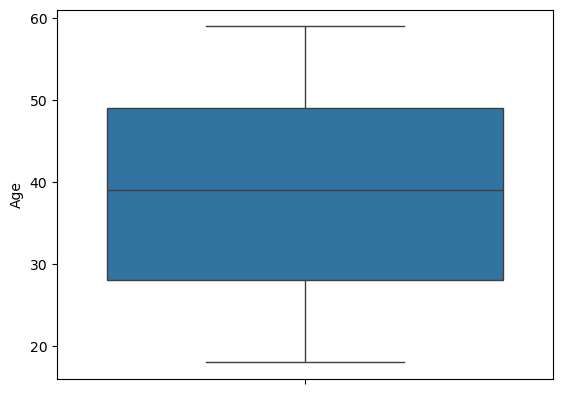

In [13]:
sns.boxplot(df['Age'])

In [14]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [15]:
df.isnull().sum()

Employee ID                             0
Age                                     0
Gender                                  0
Years at Company                        0
Number of Employee in  Department     252
Job-Roll                                0
Company Category                        0
State                                   0
City                                    0
Region                                  0
Monthly Income                       1653
Work-Life Balance                       0
Job Satisfaction                        0
Performance Rating                      0
Number of Promotions                    0
Overtime                                0
Bonus                                   0
Increments                              0
No of Leaves                          323
Employee Hire Type                      0
Distance from Home in km             1912
Education Level                         0
Marital Status                          0
Number of Dependents              

In [16]:
df['Age'].unique()

array([31., 39., 26., 56., 40., 58., 30., 35., 22., 41., 29., 18., 38.,
       47., 49., 42., 53., 50., 45., 43., 46., 51., 24., 36., 59., 34.,
       23., 25., 27., 48., 21., 55., 28., 52., 37., 33., 20., 19., 32.,
       44., 54., 57.])

# Filling The Null Values in the Column of 'Number of Employee in  Department'

In [17]:
df['Number of Employee in  Department'].isnull().sum()


252

In [18]:
# Rename the Column
df.rename(columns={'Number of Employee in  Department': 'Number of Employees in Department'}, inplace=True)


In [19]:
df.head(1)

,Employee ID,Age,Gender,Years at Company,Number of Employees in Department,Job-Roll,Company Category,State,City,Region,...,Number of Dependents,Job Level,Company Size,Company Tenure (In Months),Remote Work,Leadership Opportunities,Innovation Opportunities,Reputation of employee,Employee Recognition,Attrition
0,8410,31.0,Male,19,6.0,Administration,Media,Rj,Ajmer,North,...,0,Mid,Medium,89.0,No,No,No,Excellent,Medium,Stayed


In [20]:
df['Number of Employees in Department'].isnull().sum()

252

In [21]:
df['Number of Employees in Department'] = pd.to_numeric(df['Number of Employees in Department'], errors='coerce')


In [22]:
df['Number of Employees in Department'].describe()


count    74358.000000
mean        25.039525
std         14.712478
min          0.000000
25%         12.000000
50%         25.000000
75%         38.000000
max         50.000000
Name: Number of Employees in Department, dtype: float64

In [23]:
q1=df['Number of Employees in Department'].quantile(0.25)
q1

12.0

In [24]:
q3=df['Number of Employees in Department'].quantile(0.75)
q3

38.0

In [25]:
iqr=q1-q3
iqr

-26.0

In [26]:
ub=q3+1.5*iqr
ub

-1.0

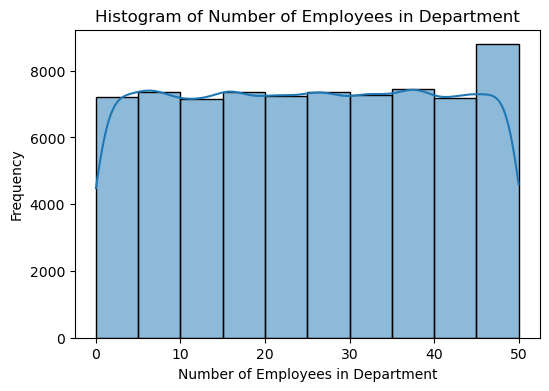

In [27]:
plt.figure(figsize=(6,4))
sns.histplot(df['Number of Employees in Department'],bins=10,kde=True)
plt.xlabel('Number of Employees in Department')
plt.ylabel('Frequency')
plt.title('Histogram of Number of Employees in Department')
plt.show()

In [28]:
df['Number of Employees in Department'] = df['Number of Employees in Department'].fillna(df['Number of Employees in Department'].median())

In [29]:
df['Number of Employees in Department']

0         6.0
1        38.0
2        45.0
3        12.0
4        37.0
         ... 
74605    49.0
74606    23.0
74607     1.0
74608    29.0
74609    10.0
Name: Number of Employees in Department, Length: 74610, dtype: float64

In [30]:
df['Number of Employees in Department'].unique()

array([ 6., 38., 45., 12., 37., 17., 13., 27., 39., 35., 25., 36., 16.,
       48.,  7., 28., 22., 26., 19.,  2., 31., 32., 34., 20., 14., 21.,
       40.,  0., 43., 47., 15., 18., 42.,  9., 10., 44., 41., 11., 33.,
        4., 49., 30.,  1., 46., 24.,  3., 29., 23., 50.,  5.,  8.])

In [31]:
df.isnull().sum()


Employee ID                             0
Age                                     0
Gender                                  0
Years at Company                        0
Number of Employees in Department       0
Job-Roll                                0
Company Category                        0
State                                   0
City                                    0
Region                                  0
Monthly Income                       1653
Work-Life Balance                       0
Job Satisfaction                        0
Performance Rating                      0
Number of Promotions                    0
Overtime                                0
Bonus                                   0
Increments                              0
No of Leaves                          323
Employee Hire Type                      0
Distance from Home in km             1912
Education Level                         0
Marital Status                          0
Number of Dependents              

# Filling The Null Values in the Column of 'Monthly Income'

In [32]:
df['Monthly Income'].isnull().sum()

1653

In [33]:
df['Monthly Income'].unique()

array([ 47368., 132176.,  93192., ...,  44298., 128914., 129554.])

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74610 entries, 0 to 74609
Data columns (total 33 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Employee ID                        74610 non-null  int64  
 1   Age                                74610 non-null  float64
 2   Gender                             74610 non-null  object 
 3   Years at Company                   74610 non-null  int64  
 4   Number of Employees in Department  74610 non-null  float64
 5   Job-Roll                           74610 non-null  object 
 6   Company Category                   74610 non-null  object 
 7   State                              74610 non-null  object 
 8   City                               74610 non-null  object 
 9   Region                             74610 non-null  object 
 10  Monthly Income                     72957 non-null  float64
 11  Work-Life Balance                  74610 non-null  obj

In [35]:
df['Monthly Income'] = pd.to_numeric(df['Monthly Income'], errors='coerce')
df['Monthly Income']

0         47368.0
1        132176.0
2         93192.0
3         28021.0
4         19566.0
           ...   
74605         NaN
74606         NaN
74607         NaN
74608         NaN
74609    129554.0
Name: Monthly Income, Length: 74610, dtype: float64

In [36]:
df['Monthly Income'].describe()

count     72957.000000
mean      80937.480461
std       39760.599443
min       12002.000000
25%       46441.000000
50%       81157.000000
75%      115221.000000
max      149999.000000
Name: Monthly Income, dtype: float64

# Using Quantile

In [37]:
df['Monthly Income'].isna().sum()

1653

<Axes: ylabel='Monthly Income'>

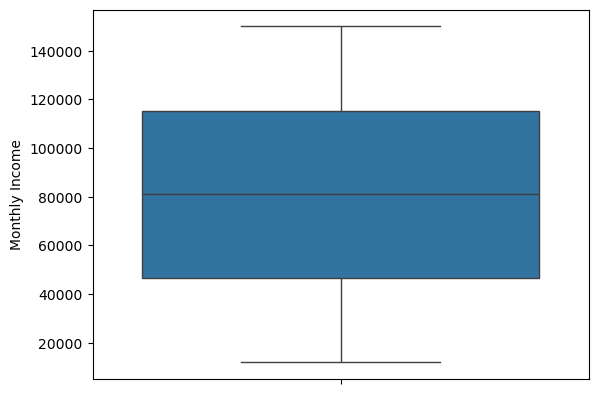

In [38]:
sns.boxplot(df['Monthly Income'])

In [39]:
q1=df['Monthly Income'].quantile(0.25)
q1

46441.0

In [40]:
q3=df['Monthly Income'].quantile(0.75)
q3

115221.0

In [41]:
iqr1=q1-q3
iqr1

-68780.0

In [42]:
ub=q3+1.5*iqr1
ub

12051.0

In [43]:
lb=q3-1.5*iqr1
lb

218391.0

### Using the Median

In [44]:
median_income=df['Monthly Income'].median()
median_income

81157.0

In [45]:
fillna =df['Monthly Income'].fillna(median_income, inplace=True)
fillna

In [46]:
df.isna().sum()

Employee ID                             0
Age                                     0
Gender                                  0
Years at Company                        0
Number of Employees in Department       0
Job-Roll                                0
Company Category                        0
State                                   0
City                                    0
Region                                  0
Monthly Income                          0
Work-Life Balance                       0
Job Satisfaction                        0
Performance Rating                      0
Number of Promotions                    0
Overtime                                0
Bonus                                   0
Increments                              0
No of Leaves                          323
Employee Hire Type                      0
Distance from Home in km             1912
Education Level                         0
Marital Status                          0
Number of Dependents              

<Axes: ylabel='No of Leaves'>

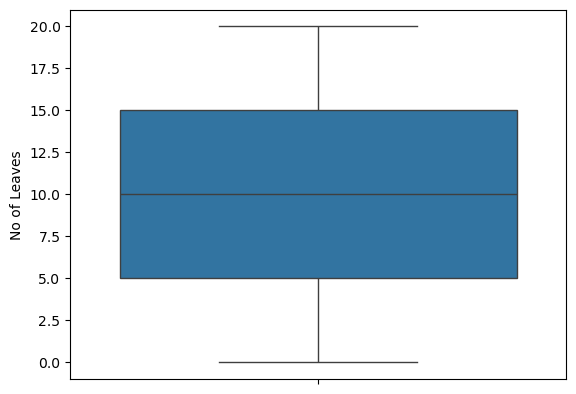

In [47]:
sns.boxplot(df['No of Leaves'])

In [48]:
df['No of Leaves'].unique()

array([15.,  9., 19., 17., 10., 12., nan,  3.,  5.,  6., 13., 14.,  0.,
       18., 16., 11.,  8.,  1.,  2.,  4., 20.,  7.])

In [49]:
q1=df['No of Leaves'].quantile(0.25)
q1

5.0

In [50]:
q3=df['No of Leaves'].quantile(0.75)
q3

15.0

In [51]:
iqr2=q3-q1

In [52]:
iqr2

10.0

In [53]:
df['o of Leaves']

KeyError: 'o of Leaves'

In [ ]:
df['No of Leaves'] = df['No of Leaves'].fillna(df['No of Leaves'].median())
df['No of Leaves']

In [ ]:
df['No of Leaves'].unique()

In [ ]:
df.isnull().sum()

# Filling The Null Values in the Column of 'Distance from Home in km'

In [ ]:
df['Distance from Home in km'].unique()

In [ ]:
df['Distance from Home in km'] = df['Distance from Home in km'].fillna('Not Specified')


In [ ]:
df.isnull().sum()

In [ ]:
df.describe()

# Filling The Null Values in the Column of 'Company Tenure (In Months)'

# Using IQR

In [ ]:
q1=df['Company Tenure (In Months)'].quantile(0.25)
q1

In [ ]:
q3=df['Company Tenure (In Months)'].quantile(0.75)
q3

In [ ]:
iqr3=q3-q1
iqr3

In [ ]:
lb=q1-1.5*iqr3
lb

In [ ]:
ub=q1+1.5*iqr3
ub

In [ ]:
sns.histplot(df['Company Tenure (In Months)'], bins=10, kde=True)
plt.xlabel('Company Tenure (In Months)')
plt.ylabel('Frequency')
plt.title('Histogram of Company Tenure (In Months)')
plt.show()


In [ ]:
df['Company Tenure (In Months)'] = (df['Company Tenure (In Months)'].fillna(df['Company Tenure (In Months)'].median()))
df['Company Tenure (In Months)']

In [ ]:
df.isnull().sum()

# Cleaning the Data

In [ ]:
df.head(2)

In [ ]:
df['Job-Roll'].unique()

In [ ]:
df['Job-Roll'] = df['Job-Roll'].replace({
    'DA': 'Data Analyst',
    'HR Executive': 'HR',
    'R & D': 'Research & Development',
    'TL': 'Team Leader',
    'Claims': 'Claims Team',
    'RM': 'Regional Manager'
})


In [ ]:
df['Job-Roll'].value_counts()


In [ ]:
df.head(1)

In [ ]:
df['Gender'] = df['Gender'].replace({
    'F': 'Female',
    'M': 'Male'
})

df['Gender']

In [ ]:
df['Gender'].unique()

In [ ]:
df.head(2)

In [ ]:
df['State'].unique()

In [ ]:
df['State']=df['State'].replace({
     'Rj': 'Rajasthan',
     'KA': 'Karnataka',
     'MH': 'Maharashtra',
     'GJ': 'Gujarat',
     'PB': 'Punjab'
})

In [ ]:
df['State'].unique()

In [ ]:
df.head(10)

# Data Visualization

In [ ]:
plt.hist(df['Age'], bins=18)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


In [ ]:
df.head(3)

In [ ]:
df.head(2)

In [ ]:
grouped = df.groupby('Company Category', as_index=False)['Monthly Income'].mean()
sns.set_style("whitegrid")
plt.figure(figsize=(9,5))
sns.scatterplot(data=grouped,
    x='Company Category',
    y='Monthly Income',
    s=200,                  
    color='#1171ba'             
)

# Title and labels
plt.title('Most Employees Work in Companies Categories', fontsize=16, fontweight='bold')
plt.xlabel('Company Category', fontsize=12)
plt.ylabel('Average Monthly Income', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12,6))

sns.countplot(
    x='State',
    hue='Company Category',
    data=df,
    order=df['State'].value_counts().head(5).index
)

plt.title('Top 5 States by Company Category Hiring')
plt.xlabel('State')
plt.ylabel('Number of Employees')
plt.legend(title='Company Category')
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure
plt.figure(figsize=(10,6))

# Violin plot
sns.violinplot(
    x='Marital Status',
    y='Company Tenure (In Months)',
    data=df,
    palette='viridis',      # Gradient-like color palette
    inner='quartile'        # Show median & quartiles
)

# Add data points (optional, swarmplot)
sns.swarmplot(
    x='Marital Status',
    y='Company Tenure (In Months)',
    data=df,
    color='k',              # black points
    alpha=0.6
)

# Titles and labels
plt.title('Distribution of Company Tenure by Marital Status', fontsize=16)
plt.xlabel('Marital Status', fontsize=12)
plt.ylabel('Company Tenure (In Months)', fontsize=12)

plt.tight_layout()
plt.show()


In [ ]:
df.head(2)

In [ ]:
df.columns


In [ ]:
df.to_csv('Clean_employee_data.csv')